# Testing Stochastic Differential Equations (SDEs)

This notebook is designed to test and visualize the behavior of stochastic differential equations (SDEs). It includes the following sections:

1. **Import Required Libraries**
2. **Define the Stochastic Differential Equation (SDE)**
3. **Simulate the SDE**
4. **Visualize the SDE Solution**
5. **Analyze Statistical Properties**

The goal is to understand the dynamics of SDEs and their statistical properties through simulation and visualization.

In [1]:
# Import Required Libraries
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sde import (
    BlackScholes1D, BlackScholes2D, BlackScholesND,
    Brownian1D, BrownianND, BSEuler1D, BSEulerND,
    BSMilstein1D, BSMilstein2D, BSMilsteinND, RandomProcess
    )
from random_generator.random_generator import RandomGenerator

print("Libraries and SDE classes imported successfully.")

Libraries and SDE classes imported successfully.


## Define the Stochastic Differential Equation (SDE)

We define the SDE in the form:

$$dX_t = \mu(X_t, t)dt + \sigma(X_t, t)dW_t$$

where:
- $\mu(X_t, t)$ is the drift term.
- $\sigma(X_t, t)$ is the diffusion term.
- $W_t$ is a Wiener process (Brownian motion).

In [2]:
# Define the SDE

def drift(x, t):
    """Drift term: μ(X_t, t)."""
    return 0.1 * x

def diffusion(x, t):
    """Diffusion term: σ(X_t, t)."""
    return 0.3 * x

# Define the initial value for the Brownian Motion
initial_value = 0.0  # Starting value for Brownian Motion

print("SDE defined with drift and diffusion terms.")

SDE defined with drift and diffusion terms.


## Simulate the SDE

We will use the Euler-Maruyama method to simulate the SDE over a given time interval. The method approximates the solution of the SDE by discretizing time and iteratively updating the state variable.

In [3]:
# Simulate Brownian Motion (1D)
from random_generator.linear_congruential import LinearCongruential
from random_generator.normal import NormalBoxMuller

time_steps = 1000
time_horizon = 1.0

uniform_gen = LinearCongruential(seed=42)
normal_gen = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_gen)
brownian = Brownian1D(generator=normal_gen)
brownian.simulate(start_time=0.0, end_time=time_horizon, nb_steps=time_steps)
brownian_path = brownian.get_path()

# Simulate Black-Scholes Model (1D)
from sde import BSEuler1D
mu = 0.05  # Drift
sigma = 0.2  # Volatility
bs_model = BSEuler1D(generator=normal_gen, spot=100, rate=mu, vol=sigma)
bs_model.simulate(start_time=0.0, end_time=time_horizon, nb_steps=time_steps)
bs_path = bs_model.get_path()

print("SDE simulations completed.")

SDE simulations completed.


Sample of generated random variables (NormalBoxMuller): [1.8918839127535865, 0.3178940625428884, -1.3434457987635546, 1.2507369942433344, 0.17646503234201408, -0.750615498320693, 0.2234061095827341, -0.03344768781434268, -1.0098242028337907, 0.33282908088613133]


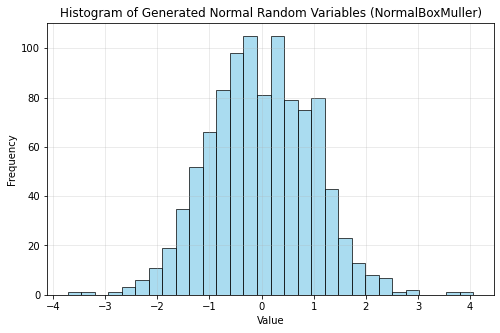

In [4]:
# Debugging: Generate and print a sample of random variables
random_samples = [normal_gen.generate() for _ in range(1000)]
print("Sample of generated random variables (NormalBoxMuller):", random_samples[:10])

# Plot histogram of generated random variables
plt.figure(figsize=(8, 5))
plt.hist(random_samples, bins=30, color="skyblue", edgecolor="black", alpha=0.7)
plt.title("Histogram of Generated Normal Random Variables (NormalBoxMuller)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

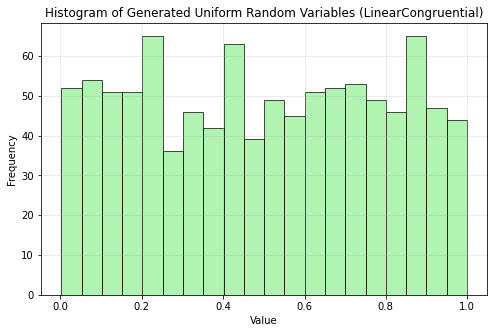

In [5]:
# Debugging: Generate and plot a histogram of uniform random variables
uniform_samples = [uniform_gen.generate() for _ in range(1000)]
plt.figure(figsize=(8, 5))
plt.hist(uniform_samples, bins=20, color="lightgreen", edgecolor="black", alpha=0.7)
plt.title("Histogram of Generated Uniform Random Variables (LinearCongruential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

## Visualize the SDE Solution

We will plot the simulated paths of the SDE to observe its behavior over time.

Shape of Brownian path values: (1001,)
Shape of Black-Scholes path values: (1001,)


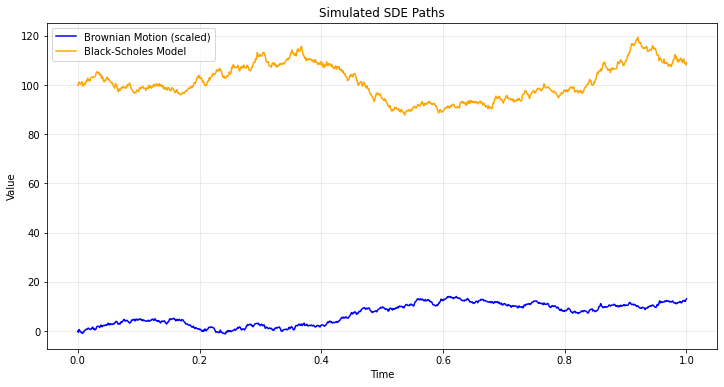

SDE paths visualized.


In [6]:
# Plot the simulated SDE paths
plt.figure(figsize=(12, 6))

# Debugging: Print shapes of the paths
print("Shape of Brownian path values:", np.shape(brownian_path.get_all_values()))
print("Shape of Black-Scholes path values:", np.shape(bs_path.get_all_values()))

# Adjust x values to match y values
scaling_factor = 10  # Scale Brownian Motion for visualization
plt.plot(np.linspace(0, time_horizon, time_steps + 1), np.array(brownian_path.get_all_values()) * scaling_factor, label="Brownian Motion (scaled)", color="blue")
plt.plot(np.linspace(0, time_horizon, time_steps + 1), bs_path.get_all_values(), label="Black-Scholes Model", color="orange")
plt.title("Simulated SDE Paths")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("SDE paths visualized.")

In [7]:
# Debugging: Print a sample of simulated paths
print("Sample of Brownian path values:", brownian_path.get_all_values()[:10])
print("Sample of Black-Scholes path values:", bs_path.get_all_values()[:10])

Sample of Brownian path values: [0.0, -0.04705175180465379, 0.06291164750338865, 0.025491212002807108, -0.002843427334455098, -0.039471602909073956, -0.06996581993468753, -0.04821861738079628, -0.08608614311994636, -0.06447404311728228]
Sample of Black-Scholes path values: [100, 100.48214694238429, 101.24198053618152, 100.82321742938177, 100.41235501368824, 100.63848468839029, 100.89401870749366, 101.38336507816196, 99.83155408198785, 99.6422792771463]


## Analyze Statistical Properties

We will compute and visualize the statistical properties of the simulated paths, such as the mean and variance.

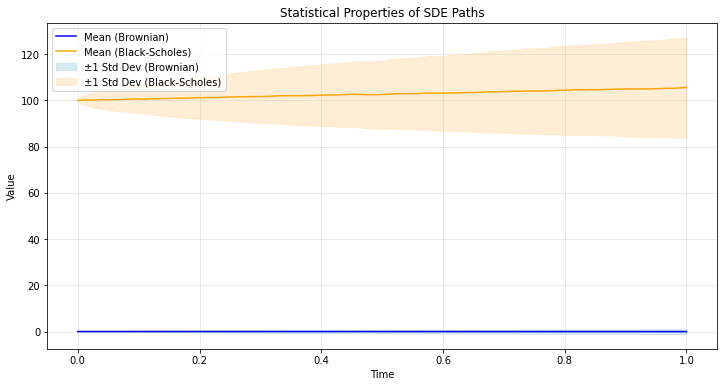

Statistical properties analyzed and visualized.


In [8]:
# Analyze statistical properties
num_paths = 1000
all_brownian_paths = np.zeros((num_paths, time_steps + 1))
all_bs_paths = np.zeros((num_paths, time_steps + 1))

for i in range(num_paths):
    brownian = Brownian1D(generator=normal_gen)
    brownian.simulate(start_time=0.0, end_time=time_horizon, nb_steps=time_steps)
    all_brownian_paths[i, :] = brownian.get_path().get_all_values()

    bs_model = BSEuler1D(generator=normal_gen, spot=100, rate=mu, vol=sigma)
    bs_model.simulate(start_time=0.0, end_time=time_horizon, nb_steps=time_steps)
    all_bs_paths[i, :] = bs_model.get_path().get_all_values()

# Compute mean and variance
mean_brownian = np.mean(all_brownian_paths, axis=0)
var_brownian = np.var(all_brownian_paths, axis=0)

mean_bs = np.mean(all_bs_paths, axis=0)
var_bs = np.var(all_bs_paths, axis=0)

# Plot mean and variance
plt.figure(figsize=(12, 6))
plt.plot(np.linspace(0, time_horizon, time_steps + 1), mean_brownian, label="Mean (Brownian)", color="blue")
plt.fill_between(np.linspace(0, time_horizon, time_steps + 1), mean_brownian - np.sqrt(var_brownian), mean_brownian + np.sqrt(var_brownian), 
                 color="lightblue", alpha=0.5, label="±1 Std Dev (Brownian)")

plt.plot(np.linspace(0, time_horizon, time_steps + 1), mean_bs, label="Mean (Black-Scholes)", color="orange")
plt.fill_between(np.linspace(0, time_horizon, time_steps + 1), mean_bs - np.sqrt(var_bs), mean_bs + np.sqrt(var_bs), 
                 color="navajowhite", alpha=0.5, label="±1 Std Dev (Black-Scholes)")

plt.title("Statistical Properties of SDE Paths")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Statistical properties analyzed and visualized.")

In [9]:
# Debugging: Print a sample of simulated paths
print("Sample of Brownian path values:", brownian_path.get_all_values()[:10])
print("Sample of Black-Scholes path values:", bs_path.get_all_values()[:10])

Sample of Brownian path values: [0.0, -0.04705175180465379, 0.06291164750338865, 0.025491212002807108, -0.002843427334455098, -0.039471602909073956, -0.06996581993468753, -0.04821861738079628, -0.08608614311994636, -0.06447404311728228]
Sample of Black-Scholes path values: [100, 100.48214694238429, 101.24198053618152, 100.82321742938177, 100.41235501368824, 100.63848468839029, 100.89401870749366, 101.38336507816196, 99.83155408198785, 99.6422792771463]


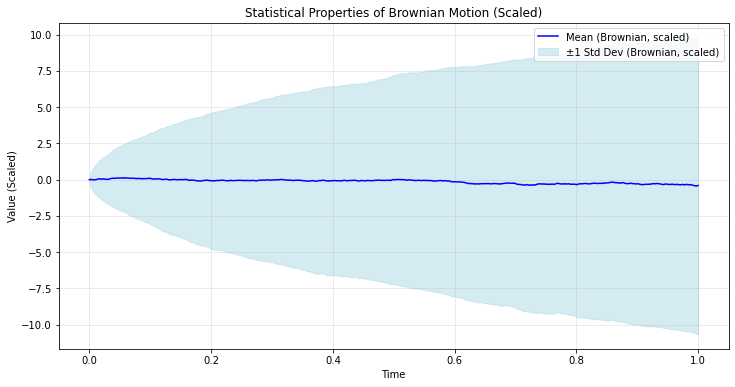

In [10]:
# Plot Brownian motion with scaling for better visibility
scaling_factor = 10
plt.figure(figsize=(12, 6))
plt.plot(np.linspace(0, time_horizon, time_steps + 1), mean_brownian * scaling_factor, label="Mean (Brownian, scaled)", color="blue")
plt.fill_between(np.linspace(0, time_horizon, time_steps + 1), (mean_brownian - np.sqrt(var_brownian)) * scaling_factor, (mean_brownian + np.sqrt(var_brownian)) * scaling_factor, 
                 color="lightblue", alpha=0.5, label="±1 Std Dev (Brownian, scaled)")
plt.title("Statistical Properties of Brownian Motion (Scaled)")
plt.xlabel("Time")
plt.ylabel("Value (Scaled)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [12]:
# Monte Carlo Simulation for European Basket Call Option
from sde import BSEulerND
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the basket option
num_assets = 3
initial_spots = [100.0, 120.0, 80.0]
rates = [0.05, 0.04, 0.03]
vols = [0.2, 0.25, 0.15]
correlation_matrix = [
    [1.0, 0.3, 0.2],
    [0.3, 1.0, 0.4],
    [0.2, 0.4, 1.0]
 ]
weights = [0.4, 0.4, 0.2]  # Portfolio weights
strike_price = 100.0  # Strike price
time_horizon = 1.0  # Maturity in years
time_steps = 252  # Number of time steps
num_paths = 10000  # Number of Monte Carlo paths

# Random generator
from random_generator.linear_congruential import LinearCongruential
from random_generator.normal import NormalBoxMuller
uniform_gen = LinearCongruential(seed=42)
normal_gen = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_gen)

# Monte Carlo simulation
payoffs = []
for _ in range(num_paths):
    # Simulate asset prices using BSEulerND
    bs_nd = BSEulerND(normal_gen, initial_spots, rates, vols, correlation_matrix)
    bs_nd.simulate(0, time_horizon, time_steps)

    # Get the terminal prices
    terminal_prices = [path.values[-1] for path in bs_nd.paths]

    # Calculate the basket value at maturity
    basket_value = sum(w * s for w, s in zip(weights, terminal_prices))

    # Calculate the payoff
    payoff = max(basket_value - strike_price, 0)
    payoffs.append(payoff)

# Calculate the option price
discount_factor = np.exp(-np.mean(rates) * time_horizon)
option_price = discount_factor * np.mean(payoffs)

# Display the result
print(f"European Basket Call Option Price: {option_price:.2f}")

European Basket Call Option Price: 11.52


European Basket Call Option Price: 7.96


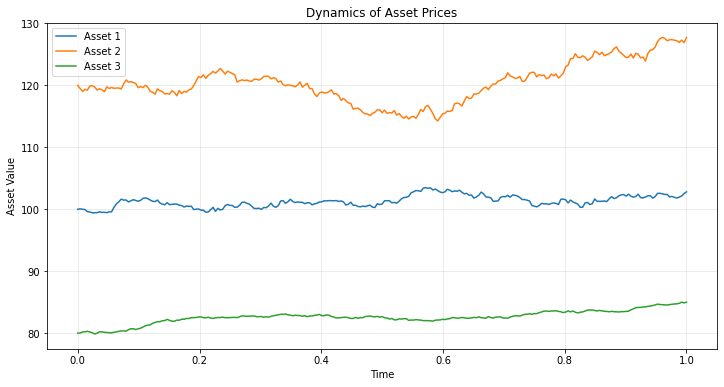

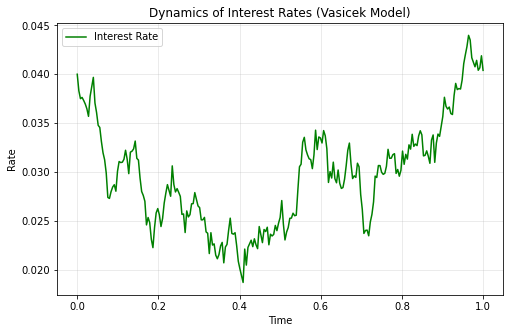

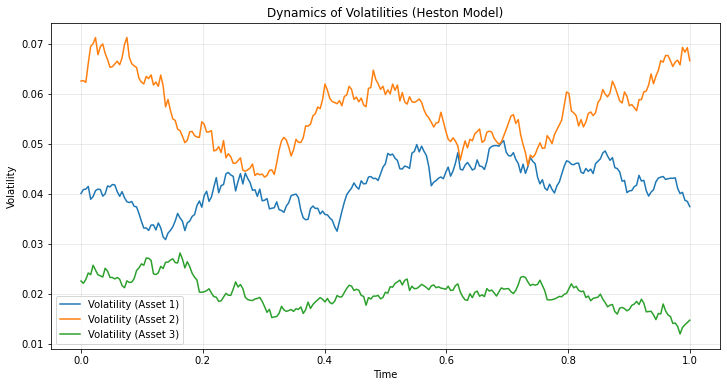

In [11]:
# Monte Carlo Simulation for European Basket Call Option with Heston and Vasicek Models
from sde import HestonModel, VasicekModel
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the basket option
num_assets = 3
initial_spots = [100.0, 120.0, 80.0]
rates = [0.05, 0.04, 0.03]
vols = [0.2, 0.25, 0.15]
correlation_matrix = [
    [1.0, 0.3, 0.2],
    [0.3, 1.0, 0.4],
    [0.2, 0.4, 1.0]
 ]
weights = [0.4, 0.4, 0.2]  # Portfolio weights
strike_price = 100.0  # Strike price
time_horizon = 1.0  # Maturity in years
time_steps = 252  # Number of time steps
num_paths = 10000  # Number of Monte Carlo paths

# Random generator
from random_generator.linear_congruential import LinearCongruential
from random_generator.normal import NormalBoxMuller
uniform_gen = LinearCongruential(seed=42)
normal_gen = NormalBoxMuller(mu=0, sigma=1, uniform=uniform_gen)

# Initialize Heston and Vasicek models
heston_models = [HestonModel(normal_gen, v0=vols[i]**2, kappa=2.0, theta=vols[i]**2, sigma=0.1, rho=0.5) for i in range(num_assets)]
vasicek_model = VasicekModel(normal_gen, r0=np.mean(rates), kappa=0.1, theta=np.mean(rates), sigma=0.02)

# Monte Carlo simulation
payoffs = []
for _ in range(num_paths):
    # Simulate rates using Vasicek model
    vasicek_model.simulate(0, time_horizon, time_steps)
    simulated_rates = vasicek_model.path

    # Simulate volatilities using Heston model
    simulated_vols = []
    for heston_model in heston_models:
        heston_model.simulate(0, time_horizon, time_steps)
        simulated_vols.append(heston_model.path)

    # Simulate asset prices using the simulated rates and volatilities
    asset_paths = []
    for i in range(num_assets):
        asset_path = [initial_spots[i]]
        for t in range(1, time_steps + 1):
            dt = time_horizon / time_steps
            drift = simulated_rates[t] * asset_path[-1] * dt
            diffusion = simulated_vols[i][t] * asset_path[-1] * np.sqrt(dt) * normal_gen.generate()
            asset_path.append(asset_path[-1] + drift + diffusion)
        asset_paths.append(asset_path)

    # Get the terminal prices
    terminal_prices = [path[-1] for path in asset_paths]

    # Calculate the basket value at maturity
    basket_value = sum(w * s for w, s in zip(weights, terminal_prices))

    # Calculate the payoff
    payoff = max(basket_value - strike_price, 0)
    payoffs.append(payoff)

# Calculate the option price
discount_factor = np.exp(-np.mean(rates) * time_horizon)
option_price = discount_factor * np.mean(payoffs)

# Display the result
print(f"European Basket Call Option Price: {option_price:.2f}")

# Plot the dynamics of assets, rates, and volatilities
time_steps_array = np.linspace(0, time_horizon, time_steps + 1)

# Plot asset dynamics
plt.figure(figsize=(12, 6))
for i, path in enumerate(asset_paths):
    plt.plot(time_steps_array, path, label=f"Asset {i+1}")
plt.title("Dynamics of Asset Prices")
plt.xlabel("Time")
plt.ylabel("Asset Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot rate dynamics
plt.figure(figsize=(8, 5))
plt.plot(time_steps_array, simulated_rates, label="Interest Rate", color="green")
plt.title("Dynamics of Interest Rates (Vasicek Model)")
plt.xlabel("Time")
plt.ylabel("Rate")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Plot volatility dynamics
plt.figure(figsize=(12, 6))
for i, vol_path in enumerate(simulated_vols):
    plt.plot(time_steps_array, vol_path, label=f"Volatility (Asset {i+1})")
plt.title("Dynamics of Volatilities (Heston Model)")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.grid(alpha=0.3)
plt.show()